# Find Event

In [3]:
from turbo_seti.find_event.find_event_pipeline import find_event_pipeline

dat_list = (
    "/datax/scratch/wlll2x/"
    "carmen_midres_bliss_combined/"
    "cadence_000/"
    "all.lst"
)

h5_list = (
    "/datax/scratch/wlll2x/"
    "carmen_midres/"
    "cadence_000/"
    "all.lst"
)


events = find_event_pipeline(
    dat_list,
    h5_list,
    filter_threshold=3,
    check_zero_drift=False,
    SNR_cut=10,
    on_off_first="ON",
    number_in_cadence=6,
    saving=True,
    csv_name="carmen_midres_cadence000_events.csv"
)


print(events)


===========   BEGINNING FIND_EVENT PIPELINE   ===========

Assuming the first observation is an ON
find_event_pipeline INFO     file=blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.dat, tstart=58832.09780092593, source_name=NGC7640, fch1=1688.9634132385254, foff=-0.00286102294921875, nchans=65536
find_event_pipeline INFO     file=blc73_guppi_58832_08767_HIP115723_0034.gpuspec.0002.dat, tstart=58832.10146990741, source_name=HIP115723, fch1=1688.9634132385254, foff=-0.00286102294921875, nchans=65536
find_event_pipeline INFO     file=blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002.dat, tstart=58832.10513888889, source_name=NGC7640, fch1=1688.9634132385254, foff=-0.00286102294921875, nchans=65536
find_event_pipeline INFO     file=blc73_guppi_58832_09400_HIP115106_0036.gpuspec.0002.dat, tstart=58832.1087962963, source_name=HIP115106, fch1=1688.9634132385254, foff=-0.00286102294921875, nchans=65536
find_event_pipeline INFO     file=blc73_guppi_58832_09716_NGC7640_0037.gpuspec.0002.dat, 

In [ ]:
from blimpy import Waterfall

wf = Waterfall("your_file.h5")
h = wf.header

print(h["fch1"])
print(h["foff"])
print(h["nchans"])

fch1 = h["fch1"]
foff = h["foff"]
nchans = h["nchans"]

f_end = fch1 + foff * nchans

print("Start:", fch1)
print("End:", f_end)

In [6]:
from blimpy import Waterfall
from pathlib import Path

# Base directory containing the cadence folders
BASE = Path("/datax/scratch/wlll2x/carmen_midres")

NCOARSE = 64

for cadence in ["cadence_000", "cadence_001", "cadence_002"]:

    print("=" * 80)
    print(cadence)
    print("=" * 80)

    lst = BASE / cadence / "all.lst"

    with open(lst) as f:
        files = [line.strip() for line in f if line.strip()]

    for filename in files:

        wf = Waterfall(filename, load_data=False)
        h = wf.header

        fch1 = float(h["fch1"])
        foff = float(h["foff"])
        nchans = int(h["nchans"])

        f_end = fch1 + foff * nchans

        bandwidth = abs(foff) * nchans
        coarse_bw = bandwidth / NCOARSE

        print(f"\n{Path(filename).name}")
        print(f"  Source           : {h['source_name']}")
        print(f"  fch1             : {fch1:.6f} MHz")
        print(f"  f_end            : {f_end:.6f} MHz")
        print(f"  nchans           : {nchans}")
        print(f"  foff             : {foff:.9f} MHz/channel")
        print(f"  Total bandwidth  : {bandwidth:.6f} MHz")
        print(f"  Coarse bandwidth : {coarse_bw:.6f} MHz ({NCOARSE} coarse channels)")

print(f"\nFinished {cadence}\n")

cadence_000

blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.h5
  Source           : NGC7640
  fch1             : 1688.963413 MHz
  f_end            : 1501.463413 MHz
  nchans           : 65536
  foff             : -0.002861023 MHz/channel
  Total bandwidth  : 187.500000 MHz
  Coarse bandwidth : 2.929688 MHz (64 coarse channels)

blc73_guppi_58832_08767_HIP115723_0034.gpuspec.0002.h5
  Source           : HIP115723
  fch1             : 1688.963413 MHz
  f_end            : 1501.463413 MHz
  nchans           : 65536
  foff             : -0.002861023 MHz/channel
  Total bandwidth  : 187.500000 MHz
  Coarse bandwidth : 2.929688 MHz (64 coarse channels)

blc73_guppi_58832_09084_NGC7640_0035.gpuspec.0002.h5
  Source           : NGC7640
  fch1             : 1688.963413 MHz
  f_end            : 1501.463413 MHz
  nchans           : 65536
  foff             : -0.002861023 MHz/channel
  Total bandwidth  : 187.500000 MHz
  Coarse bandwidth : 2.929688 MHz (64 coarse channels)

blc73_guppi_58832_09

# Histogram

In [2]:
import pandas as pd
from pathlib import Path

base = Path("/datax/scratch/wlll2x/carmen_midres_bliss_combined")

for dat in sorted(base.glob("cadence_*/*.dat")):

    # Skip the duplicate combined files
    if dat.name.endswith("_combined.dat"):
        continue

    print("=" * 80)
    print(dat.name)
    print("=" * 80)

    try:
        df = pd.read_csv(
            dat,
            comment="#",
            sep=r"\s+",
            engine="python"
        )

        print("\nColumns:")
        print(df.columns.tolist())

        print("\nFirst five rows:")
        print(df.head())

    except Exception as e:
        print("ERROR:", e)

    # Only inspect the first file
    break

blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.dat

Columns:
['000001', '0.000000', '201.782806', '1687.498569', '1687.498569.1', '512', '1687.498569.2', '1687.498569.3', '0.000000.1', '0.000000.2', '0', '2']

First five rows:
   000001  0.000000  201.782806  1687.498569  1687.498569.1  512  \
0       2 -9.584659   99.404144  1687.499995    1687.499995  511   
1       3  9.584659   98.356880  1687.500005    1687.500005  513   
2       1 -9.584659  180.947220  1684.570307    1684.570307  507   
3       2  9.584659  181.865707  1684.570318    1684.570318  509   
4       1  9.584659  139.776123  1658.203130    1658.203130  473   

   1687.498569.2  1687.498569.3  0.000000.1  0.000000.2   0  2  
0    1687.501431    1687.498559         0.0         0.0   0  3  
1    1687.498569    1687.501441         0.0         0.0   0  3  
2    1684.571743    1684.568872         0.0         0.0   1  3  
3    1684.568882    1684.571753         0.0         0.0   1  3  
4    1658.201694    1658.204566     

In [8]:
import pandas as pd
from pathlib import Path

dat = Path(
    "/datax/scratch/wlll2x/carmen_midres_bliss_combined/"
    "cadence_000/"
    "blc73_guppi_58832_08450_NGC7640_0033.gpuspec.0002.dat"
)

cols = [
    "Top_Hit",
    "Drift_Rate",
    "SNR",
    "Uncorrected_Frequency",
    "Corrected_Frequency",
    "Index",
    "freq_start",
    "freq_end",
    "SEFD_freq",
    "Coarse_Channel_Number",
    "Full_number_of_hits",
]


df = pd.read_csv(
    dat,
    sep=r"\s+",
    comment="#",
    names=cols,
    header=None,
    engine="python",
)

print(df.head())
print()
print(df.dtypes)

    Top_Hit  Drift_Rate          SNR  Uncorrected_Frequency  \
1  0.000000  201.782806  1687.498569            1687.498569   
2 -9.584659   99.404144  1687.499995            1687.499995   
3  9.584659   98.356880  1687.500005            1687.500005   
1 -9.584659  180.947220  1684.570307            1684.570307   
2  9.584659  181.865707  1684.570318            1684.570318   

   Corrected_Frequency        Index   freq_start  freq_end  SEFD_freq  \
1                  512  1687.498569  1687.498569       0.0        0.0   
2                  511  1687.501431  1687.498559       0.0        0.0   
3                  513  1687.498569  1687.501441       0.0        0.0   
1                  507  1684.571743  1684.568872       0.0        0.0   
2                  509  1684.568882  1684.571753       0.0        0.0   

   Coarse_Channel_Number  Full_number_of_hits  
1                      0                    2  
2                      0                    3  
3                      0              

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


BASE = Path(
    "/datax/scratch/wlll2x/carmen_midres_bliss_combined_middrift"
)

cadences = [
    "cadence_000",
    "cadence_001",
    "cadence_002",
]


cols = [
    "Top_Hit",
    "Drift_Rate",
    "SNR",
    "Uncorrected_Frequency",
    "Corrected_Frequency",
    "Index",
    "freq_start",
    "freq_end",
    "SEFD_freq",
    "Coarse_Channel_Number",
    "Full_number_of_hits",
]


all_drifts = {}


for cadence in cadences:

    print("\n==============================")
    print(cadence)
    print("==============================")

    files = sorted(
        (BASE / cadence).glob("*.dat")
    )

    files = [
        f for f in files
        if "_combined" not in f.name
    ]

    print("Files:", len(files))


    drifts = []


    for dat in files:

        df = pd.read_csv(
            dat,
            sep=r"\s+",
            comment="#",
            names=cols,
            header=None,
            index_col=False,
            engine="python"
        )


        print("\nCHECK:")
        print(
            df[
                [
                    "Top_Hit",
                    "Drift_Rate",
                    "SNR"
                ]
            ].head()
        )


        df["Drift_Rate"] = pd.to_numeric(
            df["Drift_Rate"],
            errors="coerce"
        )


        drifts.extend(
            df["Drift_Rate"].dropna()
        )


    all_drifts[cadence] = drifts


    print("\nHits:", len(drifts))
    print(
        "Min drift:",
        min(drifts)
    )

    print(
        "Max drift:",
        max(drifts)
    )

    print(
        "Unique drift:",
        sorted(set(drifts))
    )



combined = []

for cadence in cadences:
    combined.extend(
        all_drifts[cadence]
    )


print("\n==============================")
print("TOTAL")
print("==============================")

print("Hits:", len(combined))
print("Min:", min(combined))
print("Max:", max(combined))

print(
    sorted(set(combined))
)



plt.figure(figsize=(10,6))

plt.hist(
    combined,
    bins=50
)

plt.xlabel(
    "Drift Rate (Hz/s)"
)

plt.ylabel(
    "Number of Hits"
)

plt.title(
    "BLISS Drift Rate Distribution Carmen Midres"
)

plt.grid()

plt.tight_layout()

plt.savefig(
    "BLISS_drift_hist.png",
    dpi=300
)

plt.show()


cadence_000
Files: 0

Hits: 0


ValueError: min() arg is an empty sequence

Number of BLISS files: 7

h5spliced_blc10111213141516o7o0212223242526o7o031323334353637_guppi_59256_66265_DIAG_Mars2020_0011.rawspec.0002_coarse968.dat
   Top_Hit  Drift_Rate         SNR
0        1  -28.753978   57.663116
1        2   47.923296   33.142376
2        3   -9.584659   88.828133
3        4  -47.923296   33.122158
4        5   47.923296  207.932510

Hits: 28
Min drift: -47.923296
Max drift: 47.923296
Unique drift rates:
[-47.923296, -38.338637, -28.753978, -19.169318, -9.584659, 9.584659, 28.753978, 38.338637, 47.923296]

h5spliced_blc10111213141516o7o0212223242526o7o031323334353637_guppi_59256_66578_DIAG_Mars_0012.rawspec.0002_coarse968.dat
   Top_Hit  Drift_Rate        SNR
0        1  -28.753978  57.296864
1        2   47.923296  33.762718
2        3   47.923296  16.472078
3        4   -9.584659  86.862648
4        5  -47.923296  34.024426

Hits: 9
Min drift: -47.923296
Max drift: 47.923296
Unique drift rates:
[-47.923296, -38.338637, -28.753978, -9.584659, 9.584659, 28.75

/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(
/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(
/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(
/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(
/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(
/tmp/ipykernel_1349630/3195203814.py:55: ParserWarning: Length of header or name

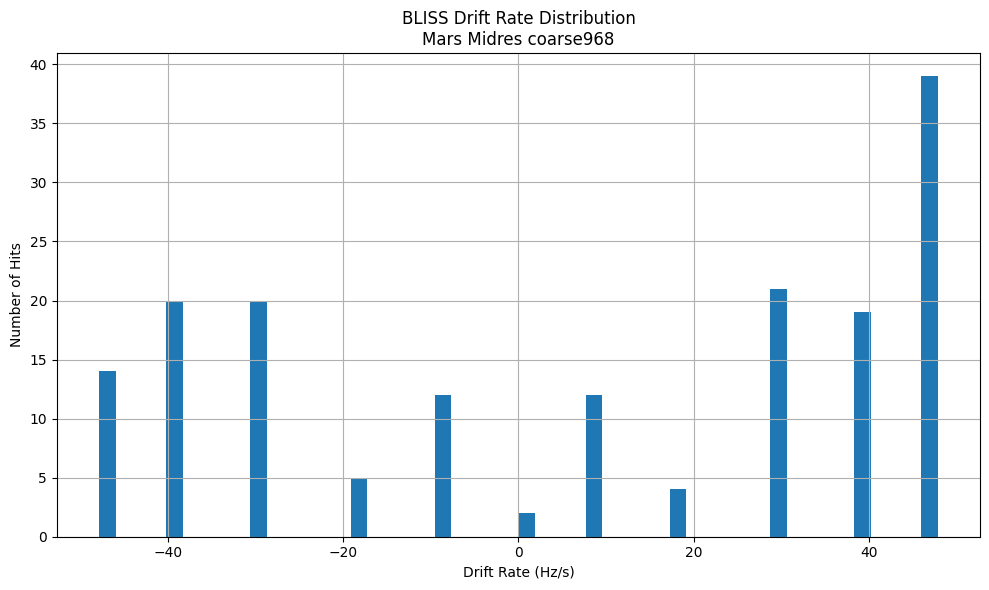

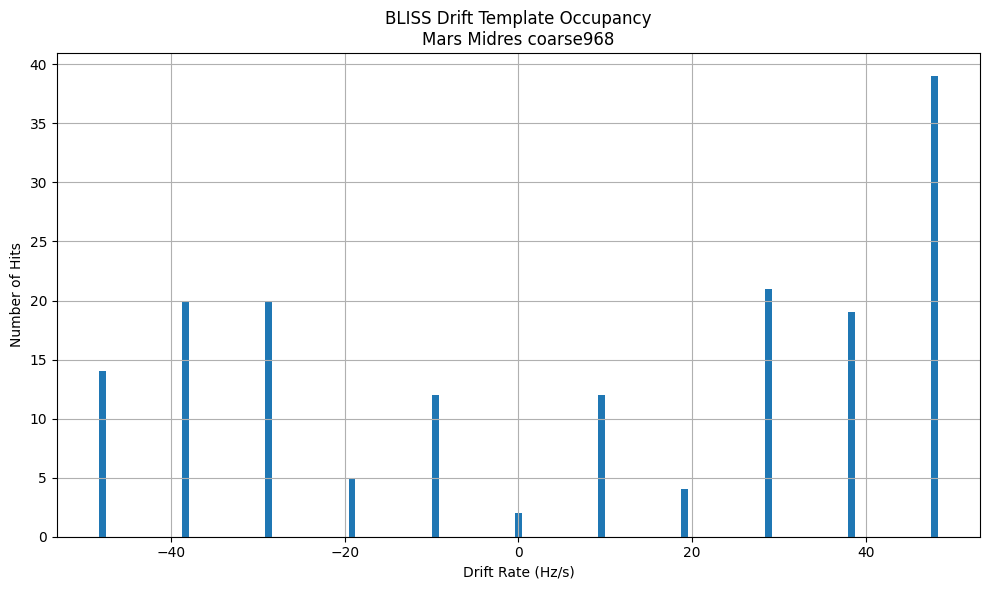

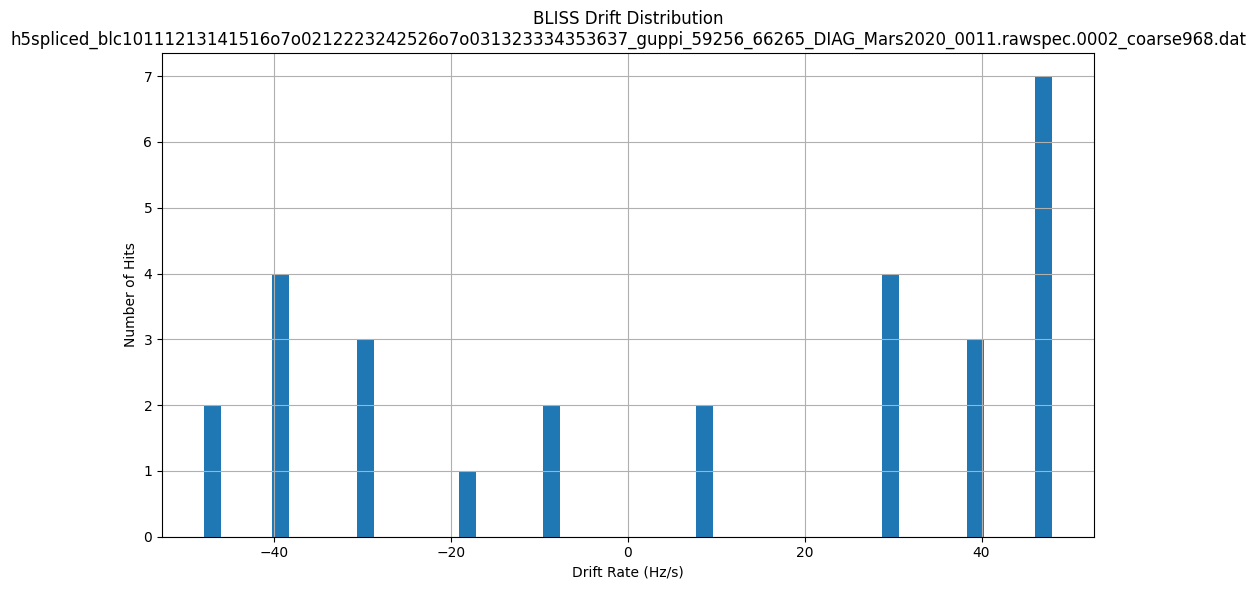

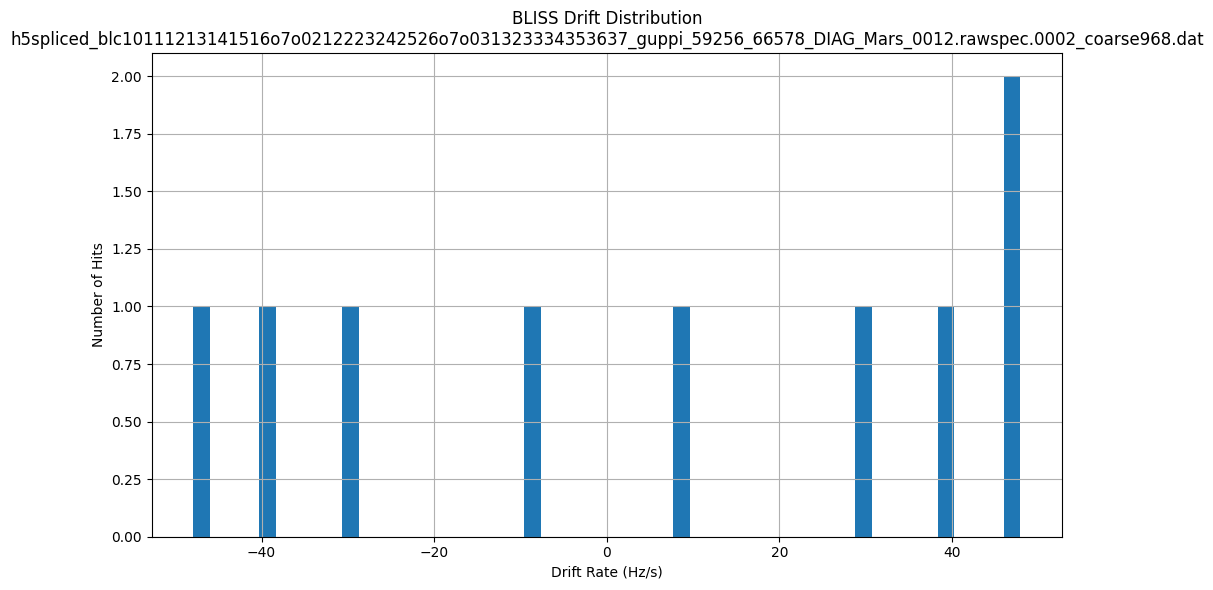

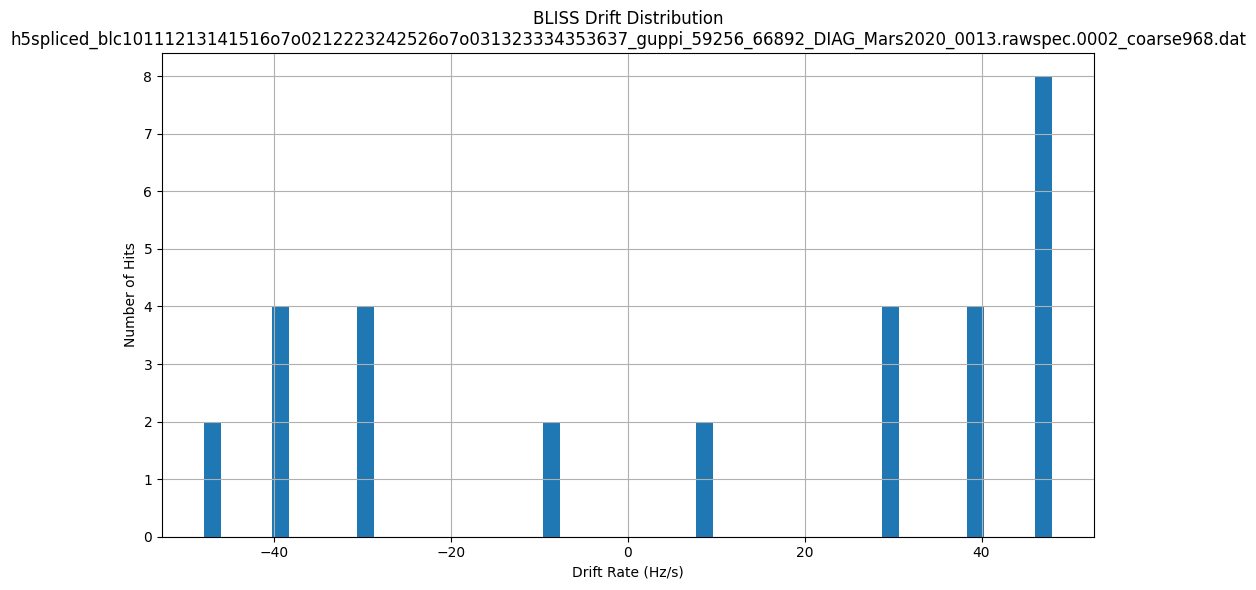

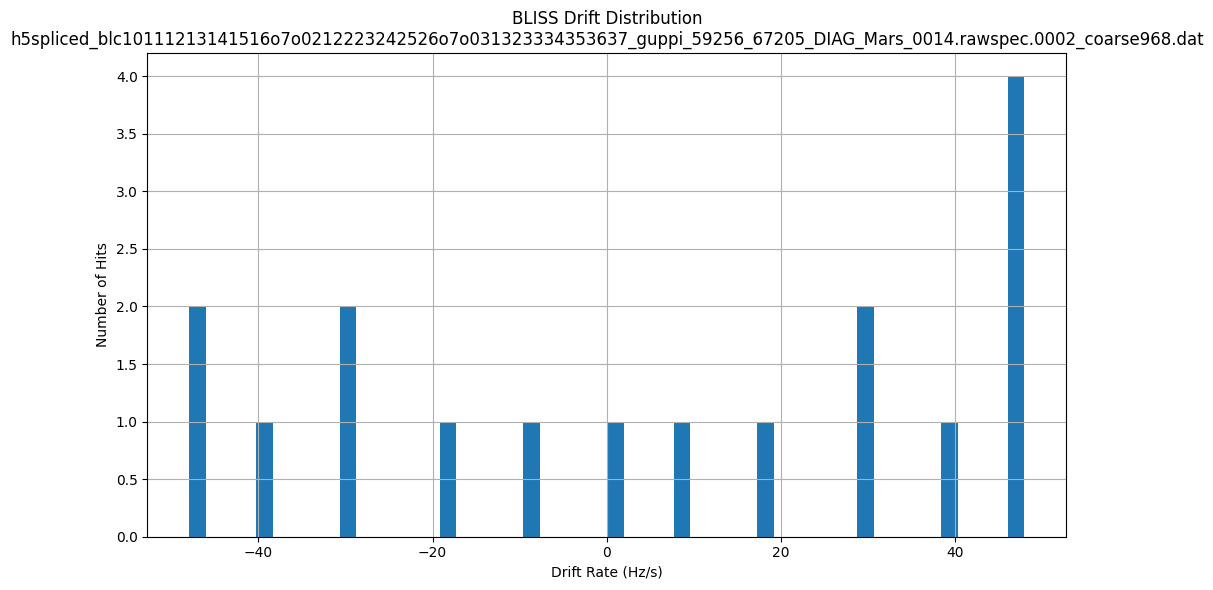

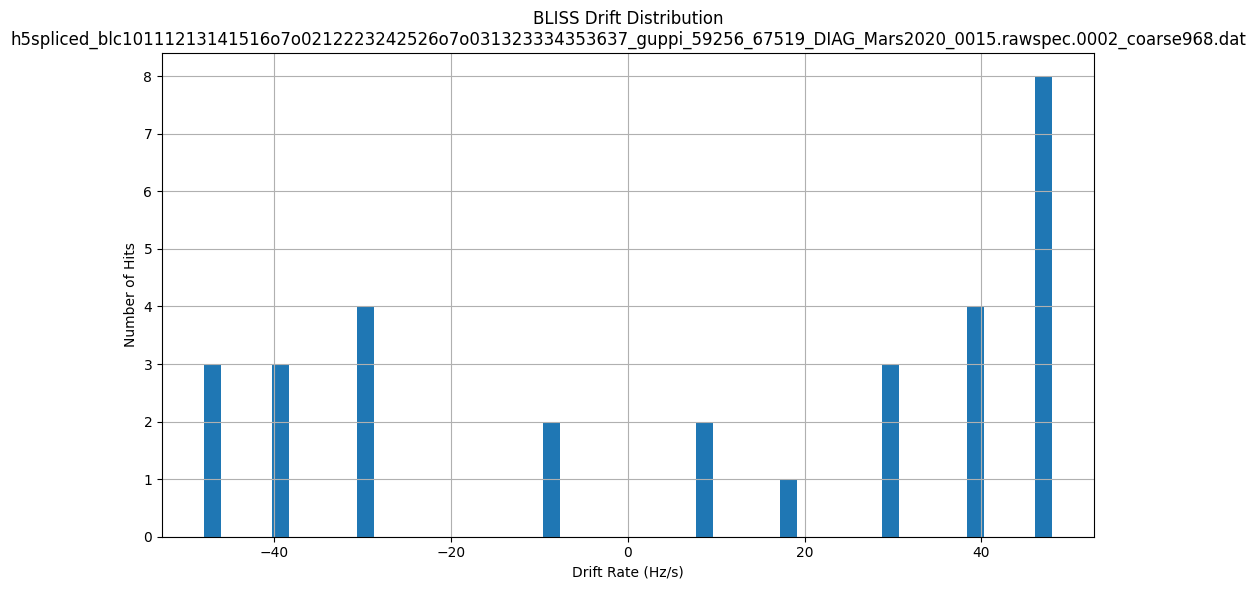

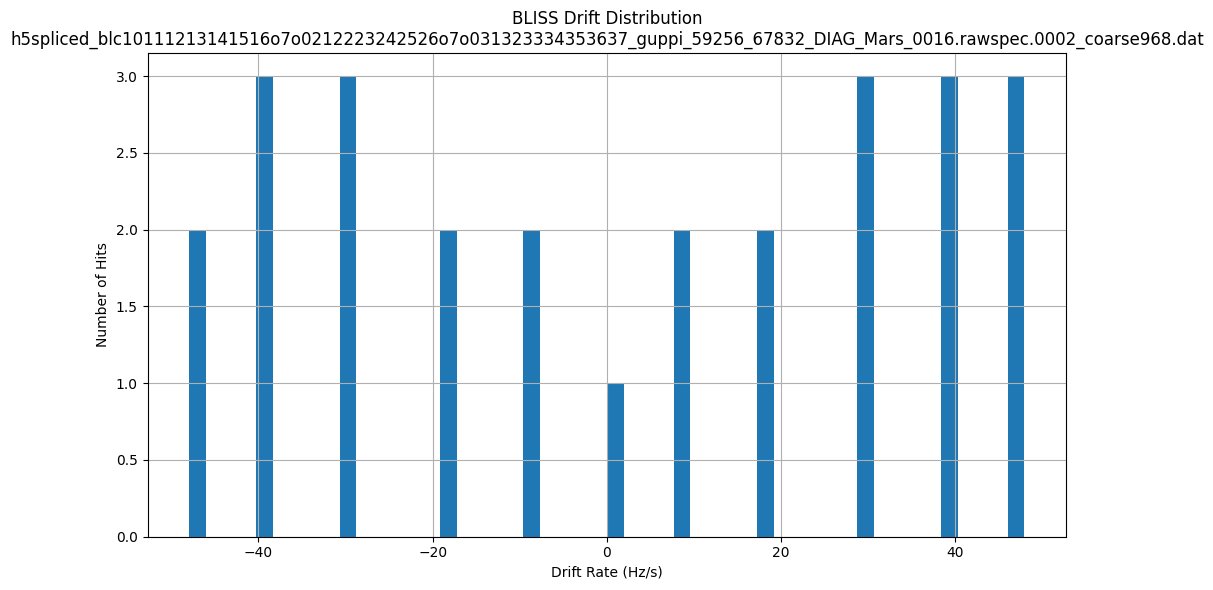

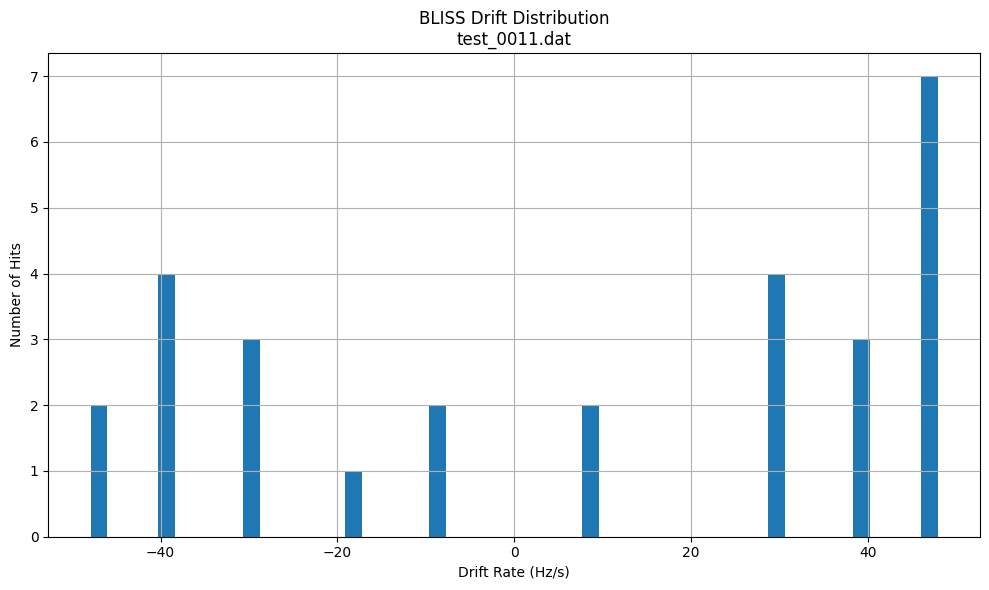

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter


# ============================================================
# Path
# ============================================================

DATA_DIR = Path(
    "/datax/scratch/wlll2x/mars_midres_bliss_coarse968"
)


# ============================================================
# BLISS columns
# ============================================================

cols = [
    "Top_Hit",
    "Drift_Rate",
    "SNR",
    "Uncorrected_Frequency",
    "Corrected_Frequency",
    "Index",
    "freq_start",
    "freq_end",
    "SEFD_freq",
    "Coarse_Channel_Number",
    "Full_number_of_hits",
]


# ============================================================
# Read files
# ============================================================

files = sorted(DATA_DIR.glob("*.dat"))

print("Number of BLISS files:", len(files))


all_drifts = []
file_drifts = {}


for dat in files:

    print("\n==============================")
    print(dat.name)
    print("==============================")


    df = pd.read_csv(
        dat,
        sep=r"\s+",
        comment="#",
        names=cols,
        header=None,
        index_col=False,
        engine="python",
    )


    # Convert drift column
    df["Drift_Rate"] = pd.to_numeric(
        df["Drift_Rate"],
        errors="coerce"
    )


    df = df.dropna(
        subset=["Drift_Rate"]
    )


    # sanity check
    print(
        df[
            [
                "Top_Hit",
                "Drift_Rate",
                "SNR"
            ]
        ].head()
    )


    drifts = df["Drift_Rate"].tolist()


    file_drifts[dat.name] = drifts

    all_drifts.extend(drifts)


    print()
    print("Hits:", len(drifts))
    print("Min drift:", min(drifts))
    print("Max drift:", max(drifts))
    print("Unique drift rates:")
    print(sorted(set(drifts)))



# ============================================================
# Total summary
# ============================================================

print("\n==============================")
print("TOTAL")
print("==============================")


print(
    "Total hits:",
    len(all_drifts)
)

print(
    "Minimum drift:",
    min(all_drifts)
)

print(
    "Maximum drift:",
    max(all_drifts)
)

print(
    "Unique drift rates:"
)

print(
    sorted(set(all_drifts))
)



# ============================================================
# Histogram
# ============================================================

plt.figure(figsize=(10,6))


plt.hist(
    all_drifts,
    bins=50
)


plt.xlabel(
    "Drift Rate (Hz/s)"
)

plt.ylabel(
    "Number of Hits"
)

plt.title(
    "BLISS Drift Rate Distribution\nMars Midres coarse968"
)


plt.grid()

plt.tight_layout()


plt.savefig(
    "mars_midres_coarse968_drift_hist.png",
    dpi=300
)


plt.show()



# ============================================================
# Drift grid occupancy
# ============================================================

counts = Counter(all_drifts)


plt.figure(figsize=(10,6))


plt.bar(
    counts.keys(),
    counts.values()
)


plt.xlabel(
    "Drift Rate (Hz/s)"
)

plt.ylabel(
    "Number of Hits"
)

plt.title(
    "BLISS Drift Template Occupancy\nMars Midres coarse968"
)


plt.grid()

plt.tight_layout()


plt.savefig(
    "mars_midres_coarse968_drift_grid.png",
    dpi=300
)


plt.show()



# ============================================================
# Individual file histograms
# ============================================================

for name, drifts in file_drifts.items():

    plt.figure(figsize=(10,6))


    plt.hist(
        drifts,
        bins=50
    )


    plt.xlabel(
        "Drift Rate (Hz/s)"
    )

    plt.ylabel(
        "Number of Hits"
    )


    plt.title(
        f"BLISS Drift Distribution\n{name}"
    )


    plt.grid()

    plt.tight_layout()


    plt.savefig(
        f"{name}_drift_hist.png",
        dpi=300
    )


    plt.show()